# DBSCAN Clustering — Parks Canada Wildlife Conflict Hotspots
### Capstone Project II

This notebook identifies geographic hotspots of HIGH risk human-wildlife conflict
across Canadian national parks using DBSCAN density-based clustering.



## Step 1 — Load Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

from google.colab import drive
drive.mount('/content/drive')

# Load the cleaned RF dataset — it already has coordinates and RISK_LEVEL
df_full = pd.read_csv('/content/drive/MyDrive/parks_canada_rf.csv')
print(f"Full dataset: {df_full.shape[0]} rows")
print(df_full['RISK_LEVEL'].value_counts())

Mounted at /content/drive
Full dataset: 55870 rows
RISK_LEVEL
HIGH      49244
LOW        5598
MEDIUM     1028
Name: count, dtype: int64


## Step 2 — Select Columns and Filter to HIGH Risk Only



In [ ]:
# Keep only what we need for clustering and interpretation
df_cluster = df_full[[
    'Latitude', 'Longitude',
    'SPECIES', 'RISK_LEVEL',
    'Field_Unit', 'Month', 'Year'
]].copy()

# Filter to HIGH risk only — these are the actual conflict incidents we want to cluster
df_cluster = df_cluster[df_cluster['RISK_LEVEL'] == 'HIGH'].copy()

# Drop any remaining nulls and duplicates
df_cluster = df_cluster.dropna(subset=['Latitude', 'Longitude'])
df_cluster = df_cluster.drop_duplicates()
df_cluster = df_cluster.reset_index(drop=True)

print(f"HIGH risk incidents ready for clustering: {df_cluster.shape[0]}")
print(f"\nTop species in HIGH risk incidents:")
print(df_cluster['SPECIES'].value_counts().head(8))

HIGH risk incidents ready for clustering: 49244

Top species in HIGH risk incidents:
SPECIES
Black Bear       19350
Elk              16869
Grizzly Bear      8552
Bighorn Sheep      884
Mule Deer          802
Coyote             706
Wolf               698
Moose              619
Name: count, dtype: int64


## Step 3 — EDA Before Clustering

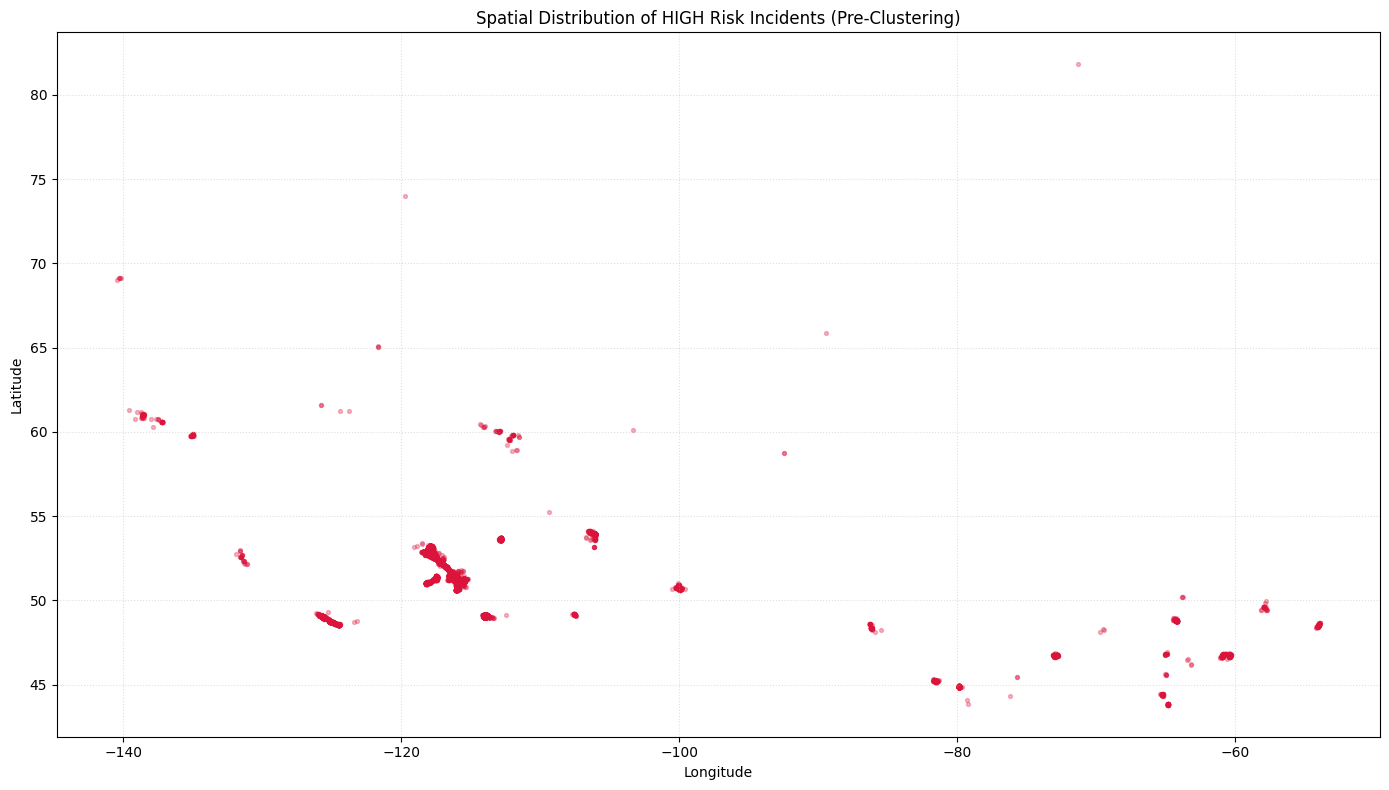

In [ ]:
# Raw spatial distribution of HIGH risk incidents across Canada
plt.figure(figsize=(14, 8))
plt.scatter(df_cluster['Longitude'], df_cluster['Latitude'],
            alpha=0.3, s=8, color='crimson')
plt.title('Spatial Distribution of HIGH Risk Incidents (Pre-Clustering)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

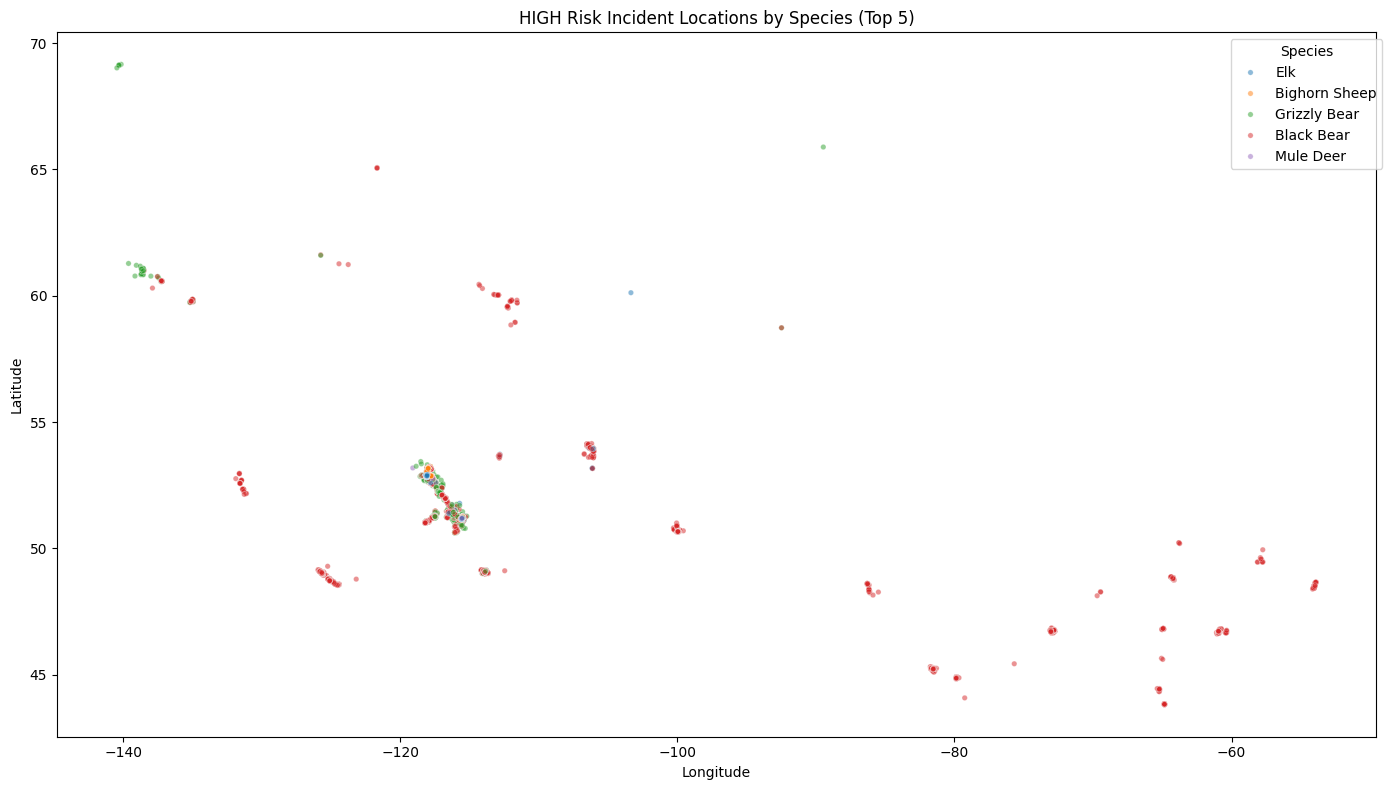

In [ ]:
# Spatial distribution by top species
top_species = df_cluster['SPECIES'].value_counts().nlargest(5).index

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_cluster[df_cluster['SPECIES'].isin(top_species)],
    x='Longitude', y='Latitude',
    hue='SPECIES', palette='tab10', alpha=0.5, s=15
)
plt.title('HIGH Risk Incident Locations by Species (Top 5)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Species', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## Step 4 — Convert Coordinates to Radians for Haversine

sklearn's DBSCAN with `metric='haversine'` requires coordinates in **radians**, not degrees.
We also convert the `eps` distance from kilometers to radians: `eps_radians = km / 6371`
(6371 is Earth's radius in km).

In [ ]:
# Convert lat/lon from degrees to radians
coords_rad = np.radians(df_cluster[['Latitude', 'Longitude']].values)
print(f"Coordinates converted to radians. Shape: {coords_rad.shape}")
print(f"Sample (first row): {coords_rad[0]}")

Coordinates converted to radians. Shape: (49244, 2)
Sample (first row): [ 0.89308754 -2.01743388]


## Step 5 — Find Optimal Epsilon (K-Distance Plot)

Same approach as Chitwan — we look for the "elbow" in the k-distance plot.
Here the distance is in radians, so we convert the elbow value to km for interpretation.

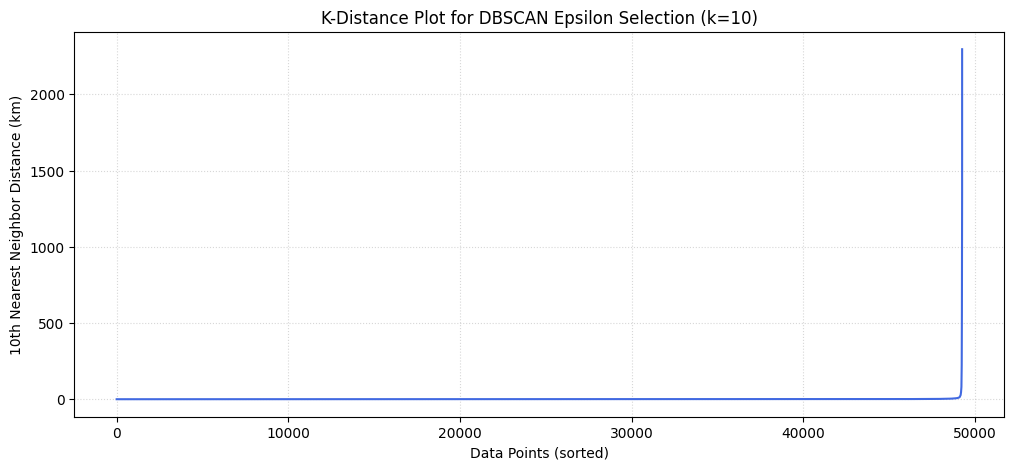

Look for the elbow (where the curve bends sharply upward).
The km value at the elbow is your eps_km.


In [ ]:
MIN_SAMPLES = 10

neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='haversine')
neigh.fit(coords_rad)
distances, _ = neigh.kneighbors(coords_rad)

# Sort the distance to the k-th nearest neighbor
distances_sorted = np.sort(distances[:, MIN_SAMPLES - 1])

# Convert radian distances to kilometers for readable axis
distances_km = distances_sorted * 6371

plt.figure(figsize=(12, 5))
plt.plot(distances_km, linewidth=1.5, color='royalblue')
plt.title(f'K-Distance Plot for DBSCAN Epsilon Selection (k={MIN_SAMPLES})')
plt.xlabel('Data Points (sorted)')
plt.ylabel(f'{MIN_SAMPLES}th Nearest Neighbor Distance (km)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

print("Look for the elbow (where the curve bends sharply upward).")
print("The km value at the elbow is your eps_km.")

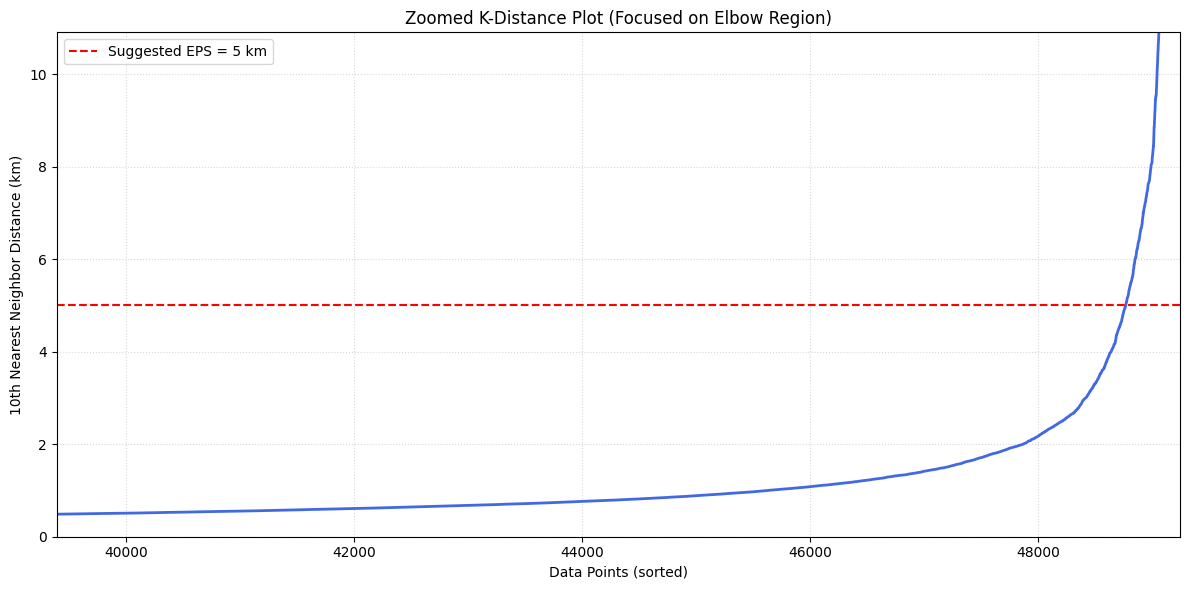

EPS = 5 km → 0.000785 radians


In [ ]:
# Zoomed-in elbow plot — adjust xlim to focus on where the curve bends
plt.figure(figsize=(12, 6))
plt.plot(distances_km, linewidth=2, color='royalblue')

# Focus on the last 20% of points where the elbow typically appears
focus_start = int(len(distances_km) * 0.80)
plt.xlim(focus_start, len(distances_km))
plt.ylim(0, distances_km[focus_start:].mean() * 3)

EPS_KM = 5  # elbow is at ~1km flat region, 5km captures it cleanly
plt.axhline(y=EPS_KM, color='red', linestyle='--',
            label=f'Suggested EPS = {EPS_KM} km')

plt.title('Zoomed K-Distance Plot (Focused on Elbow Region)')
plt.xlabel('Data Points (sorted)')
plt.ylabel(f'{MIN_SAMPLES}th Nearest Neighbor Distance (km)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Convert chosen eps from km to radians for DBSCAN
EPS_RAD = EPS_KM / 6371
print(f"EPS = {EPS_KM} km → {EPS_RAD:.6f} radians")

## Step 6 — Run DBSCAN with Haversine Distance

In [ ]:
# algorithm='ball_tree' is required when using haversine metric
dbscan = DBSCAN(
    eps=EPS_RAD,
    min_samples=MIN_SAMPLES,
    metric='haversine',
    algorithm='ball_tree'
)
df_cluster['DBSCAN_Cluster'] = dbscan.fit_predict(coords_rad)

n_clusters = len(set(df_cluster['DBSCAN_Cluster'])) - (1 if -1 in df_cluster['DBSCAN_Cluster'].values else 0)
n_noise    = (df_cluster['DBSCAN_Cluster'] == -1).sum()

print(f"Clusters found:   {n_clusters}")
print(f"Noise points:     {n_noise} ({n_noise/len(df_cluster)*100:.1f}%)")
print(f"Clustered points: {len(df_cluster) - n_noise}")

Clusters found:   40
Noise points:     333 (0.7%)
Clustered points: 48911


## Step 7 — Silhouette Score Validation

In [ ]:
# Silhouette score only works on non-noise points with at least 2 clusters
mask = df_cluster['DBSCAN_Cluster'] != -1

if df_cluster['DBSCAN_Cluster'][mask].nunique() > 1:
    # Use haversine distance for silhouette too — keeps it consistent
    db_score = silhouette_score(
        coords_rad[mask],
        df_cluster['DBSCAN_Cluster'][mask],
        metric='haversine'
    )
    print(f"DBSCAN Silhouette Score (excluding noise): {db_score:.3f}")
    print("(> 0.4 is acceptable, > 0.5 is good for geographic clustering)")
else:
    print("Not enough clusters for silhouette score. Try adjusting EPS_KM.")

DBSCAN Silhouette Score (excluding noise): 0.789
(> 0.4 is acceptable, > 0.5 is good for geographic clustering)


## Step 8 — Hotspot Interpretation Table
Identify the primary species and assign priority level
based on incident count per cluster.

In [ ]:
hotspots = df_cluster[df_cluster['DBSCAN_Cluster'] != -1].copy()

db_report = hotspots.groupby('DBSCAN_Cluster').agg(
    Incident_Count = ('SPECIES', 'count'),
    Primary_Species= ('SPECIES',   lambda x: x.mode()[0]),
    Primary_Park   = ('Field_Unit', lambda x: x.mode()[0]),
    Peak_Month     = ('Month',      lambda x: x.mode()[0]),
    Center_Lat     = ('Latitude',   'mean'),
    Center_Lon     = ('Longitude',  'mean')
).reset_index()

# Priority: CRITICAL if above 75th percentile, ACTIVE otherwise
q75 = db_report['Incident_Count'].quantile(0.75)
db_report['Priority'] = db_report['Incident_Count'].apply(
    lambda x: 'CRITICAL' if x > q75 else 'ACTIVE'
)

db_report = db_report.sort_values('Incident_Count', ascending=False)
db_report[['Center_Lat', 'Center_Lon']] = db_report[['Center_Lat', 'Center_Lon']].round(3)

print("--- DBSCAN HOTSPOT ANALYSIS ---")
print(db_report.to_string(index=False))

--- DBSCAN HOTSPOT ANALYSIS ---
 DBSCAN_Cluster  Incident_Count Primary_Species                                 Primary_Park  Peak_Month  Center_Lat  Center_Lon Priority
              4           24721             Elk                            Jasper Field Unit           6      52.859    -118.013 CRITICAL
              0           17517             Elk                             Banff Field Unit           6      51.219    -115.739 CRITICAL
              6            2096      Black Bear                    Waterton Lakes Field Unit           7      49.064    -113.927 CRITICAL
              1             875      Black Bear          Coastal British Columbia Field Unit           6      49.034    -125.689 CRITICAL
              9             692      Black Bear          Coastal British Columbia Field Unit           8      48.698    -124.942 CRITICAL
             18             541    Grizzly Bear      Mount Revelstoke And Glacier Field Unit           6      51.293    -117.520 CRITICAL
  

## Step 9 — DBSCAN Cluster Map

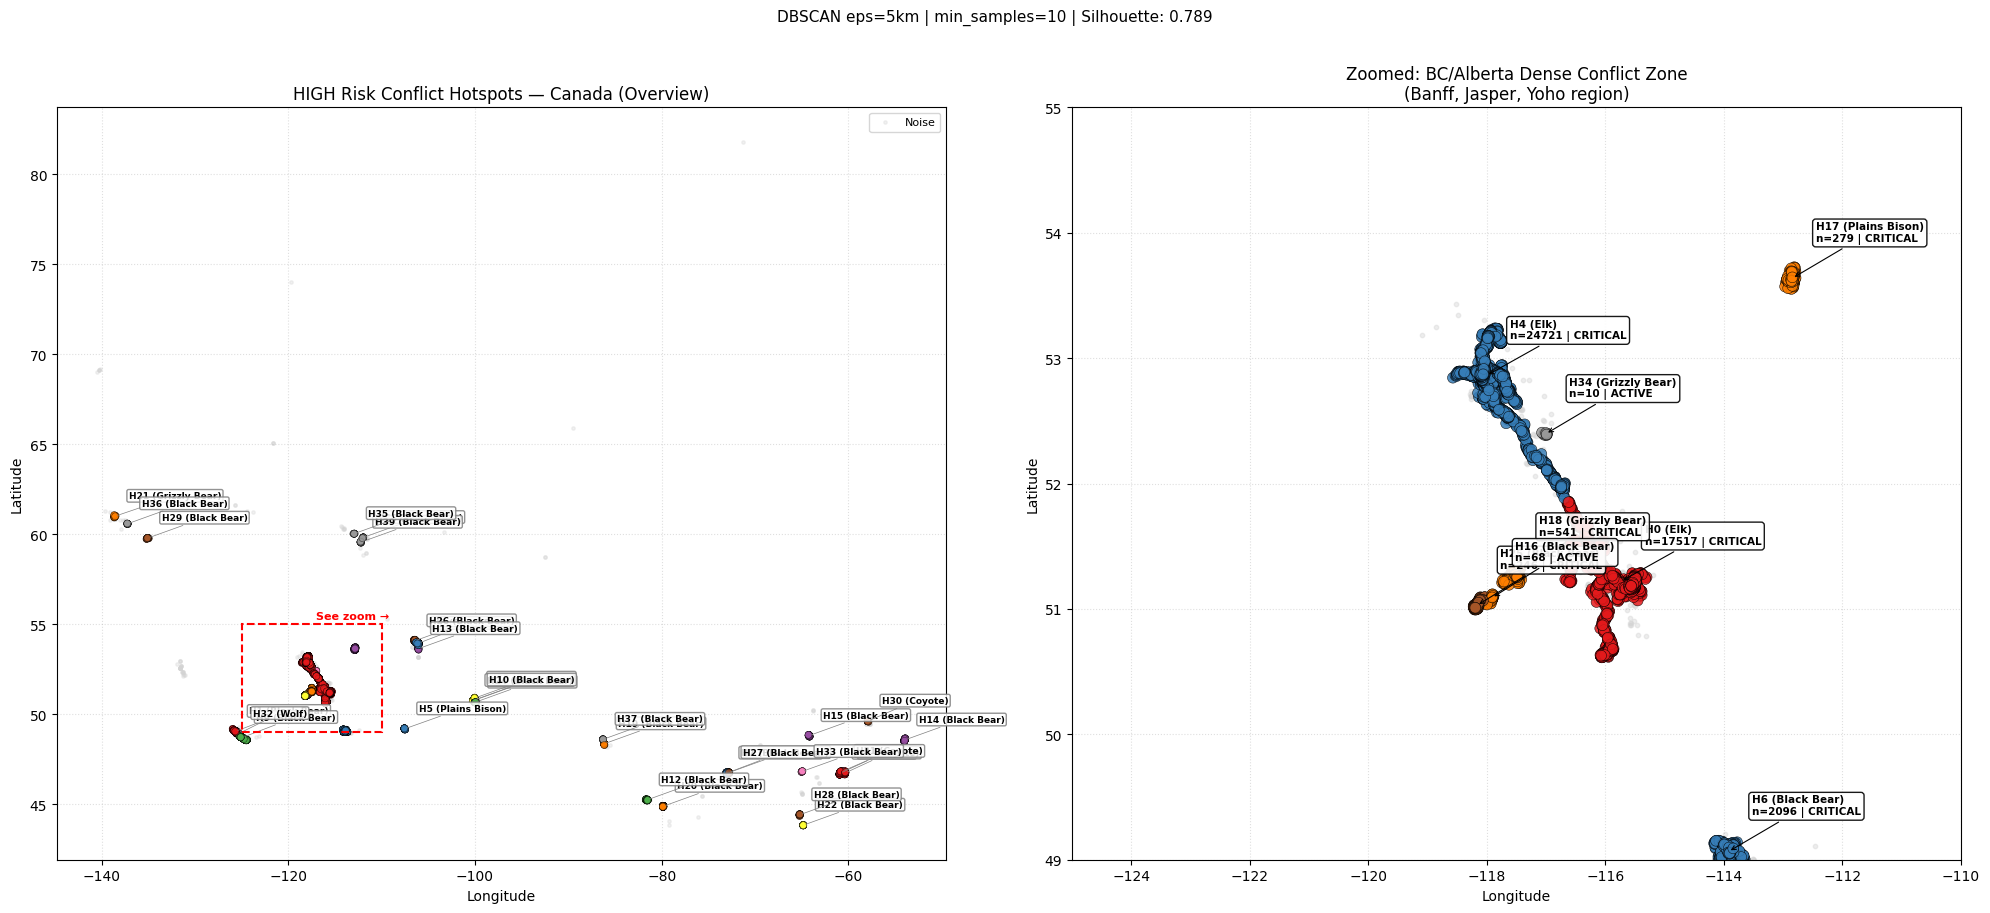

In [ ]:
clustered = df_cluster[df_cluster['DBSCAN_Cluster'] != -1]
noise     = df_cluster[df_cluster['DBSCAN_Cluster'] == -1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# ── PANEL 1: Full Canada Overview ──
ax1.scatter(noise['Longitude'], noise['Latitude'],
            c='lightgrey', s=6, alpha=0.3, label='Noise', zorder=1)
ax1.scatter(clustered['Longitude'], clustered['Latitude'],
            c=clustered['DBSCAN_Cluster'], cmap='Set1',
            s=25, edgecolors='black', linewidth=0.3, alpha=0.8, zorder=2)

# Only label clusters OUTSIDE the dense BC/Alberta zone on the overview
for _, row in db_report.iterrows():
    lon, lat = row['Center_Lon'], row['Center_Lat']
    # Skip the dense zone — it gets its own panel
    if -125 <= lon <= -110 and 49 <= lat <= 55:
        continue
    ax1.annotate(
        f"H{int(row['DBSCAN_Cluster'])} ({row['Primary_Species']})",
        xy=(lon, lat),
        xytext=(lon + 1.5, lat + 1.0),
        fontsize=6.5, weight='bold',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey',
                  boxstyle='round,pad=0.2'),
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
        zorder=3
    )

# Draw a red rectangle to show where the zoom panel is
from matplotlib.patches import Rectangle
rect = Rectangle((-125, 49), 15, 6,
                 linewidth=1.5, edgecolor='red',
                 facecolor='none', linestyle='--', zorder=4)
ax1.add_patch(rect)
ax1.text(-117, 55.3, 'See zoom →', color='red', fontsize=8, weight='bold')

ax1.set_title('HIGH Risk Conflict Hotspots — Canada (Overview)', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.legend(loc='upper right', fontsize=8)

# ── PANEL 2: Zoomed BC/Alberta Dense Region ──
# Filter to just the dense zone
zoom_clustered = clustered[
    (clustered['Longitude'] >= -125) & (clustered['Longitude'] <= -110) &
    (clustered['Latitude']  >= 49)   & (clustered['Latitude']  <= 55)
]
zoom_noise = noise[
    (noise['Longitude'] >= -125) & (noise['Longitude'] <= -110) &
    (noise['Latitude']  >= 49)   & (noise['Latitude']  <= 55)
]
zoom_report = db_report[
    (db_report['Center_Lon'] >= -125) & (db_report['Center_Lon'] <= -110) &
    (db_report['Center_Lat'] >= 49)   & (db_report['Center_Lat'] <= 55)
]

ax2.scatter(zoom_noise['Longitude'], zoom_noise['Latitude'],
            c='lightgrey', s=10, alpha=0.4, label='Noise', zorder=1)
ax2.scatter(zoom_clustered['Longitude'], zoom_clustered['Latitude'],
            c=zoom_clustered['DBSCAN_Cluster'], cmap='Set1',
            s=60, edgecolors='black', linewidth=0.4, alpha=0.85, zorder=2)

for _, row in zoom_report.iterrows():
    ax2.annotate(
        f"H{int(row['DBSCAN_Cluster'])} ({row['Primary_Species']})\n"
        f"n={int(row['Incident_Count'])} | {row['Priority']}",
        xy=(row['Center_Lon'], row['Center_Lat']),
        xytext=(row['Center_Lon'] + 0.4, row['Center_Lat'] + 0.3),
        fontsize=7.5, weight='bold',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black',
                  boxstyle='round,pad=0.3'),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
        zorder=3
    )

ax2.set_title('Zoomed: BC/Alberta Dense Conflict Zone\n(Banff, Jasper, Yoho region)',
              fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_xlim(-125, -110)
ax2.set_ylim(49, 55)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.suptitle(
    f'DBSCAN eps={EPS_KM}km | min_samples={MIN_SAMPLES} | Silhouette: {db_score:.3f}',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

## ── PCA + K-MEANS ──
## Step 10 — PCA Dimensionality Reduction

PCA + KMeans gives us a comparison baseline for DBSCAN.
Unlike DBSCAN, KMeans forces every point into a cluster (no noise),
and assumes clusters are roughly equal in size and shape — which is
rarely true for real geographic wildlife data.
This is why we expect DBSCAN to outperform it on silhouette score.

In [ ]:
# Scale lat/lon with MinMaxScaler before PCA
scaler_mm = MinMaxScaler()
coords_scaled = scaler_mm.fit_transform(df_cluster[['Latitude', 'Longitude']])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(coords_scaled)

print(f"Variance explained by PCA components: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained by PCA components: [0.877 0.123]
Total variance retained: 100.0%


## Step 11 — Find Optimal K with Elbow and Silhouette

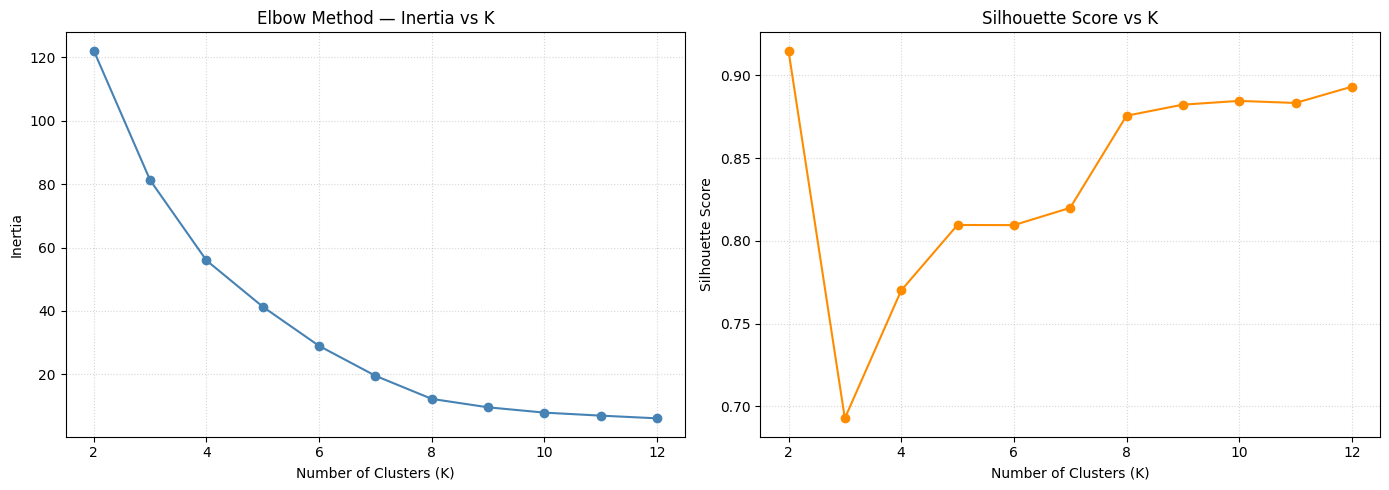

Selected K: 12 (silhouette: 0.8932)
Note: K=2 had highest silhouette (0.9149) but only split Canada West vs East —
not actionable. K=12 maps to real park regions with meaningful species patterns.


In [ ]:
# Test k values from 2 to 12 and record inertia + silhouette
k_range    = range(2, 13)
inertias   = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', color='steelblue')
ax1.set_title('Elbow Method — Inertia vs K')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.grid(True, linestyle=':', alpha=0.5)

ax2.plot(k_range, sil_scores, marker='o', color='darkorange')
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

best_k = 12  # manually set to 12 for meaningful regional interpretation
print(f"Selected K: {best_k} (silhouette: {sil_scores[k_range.index(best_k)]:.4f})")
print("Note: K=2 had highest silhouette (0.9149) but only split Canada West vs East —")
print("not actionable. K=12 maps to real park regions with meaningful species patterns.")

## Step 12 — Run KMeans with Best K

In [ ]:
km_final = KMeans(n_clusters=12, n_init=10, random_state=42)
df_cluster['PCA_Cluster'] = km_final.fit_predict(X_pca)

pca_score = silhouette_score(X_pca, df_cluster['PCA_Cluster'])
print(f"PCA-KMeans Silhouette Score: {pca_score:.4f}")

PCA-KMeans Silhouette Score: 0.8932


## Step 13 — PCA Cluster Interpretation Table

In [ ]:
pca_report = df_cluster.groupby('PCA_Cluster').agg(
    Incident_Count = ('SPECIES',    'count'),
    Primary_Species= ('SPECIES',    lambda x: x.mode()[0]),
    Primary_Park   = ('Field_Unit', lambda x: x.mode()[0]),
    Center_Lat     = ('Latitude',   'mean'),
    Center_Lon     = ('Longitude',  'mean')
).reset_index()

pca_report['Priority'] = pca_report['Incident_Count'].apply(
    lambda x: 'High' if x > pca_report['Incident_Count'].mean() else 'Medium'
)
pca_report['Action'] = pca_report['Priority'].map({
    'High':   'Immediate Intervention Deployment',
    'Medium': 'Increased Surveillance'
})

pca_report[['Center_Lat', 'Center_Lon']] = pca_report[['Center_Lat', 'Center_Lon']].round(3)

print("--- PCA-KMEANS BROAD REGION ANALYSIS ---")
print(pca_report.sort_values('Incident_Count', ascending=False).to_string(index=False))

--- PCA-KMEANS BROAD REGION ANALYSIS ---
 PCA_Cluster  Incident_Count Primary_Species                               Primary_Park  Center_Lat  Center_Lon Priority                            Action
           0           24526             Elk                          Jasper Field Unit      52.867    -118.024     High Immediate Intervention Deployment
           2           18673             Elk                           Banff Field Unit      51.229    -115.845     High Immediate Intervention Deployment
           7            2151      Black Bear                  Waterton Lakes Field Unit      49.066    -113.788   Medium            Increased Surveillance
           3            1621      Black Bear        Coastal British Columbia Field Unit      48.944    -125.454   Medium            Increased Surveillance
           4             548      Black Bear     Eastern And Central Ontario Field Unit      45.711     -79.426   Medium            Increased Surveillance
           1             486 

In [ ]:
print("--- KMeans vs DBSCAN: Why Mathematical Optimality Isn't Always Practical ---")
print(f"KMeans best silhouette was K=2 (0.9149) — but produced only West vs East Canada split")
print(f"KMeans K=12 silhouette: 0.8932 — slightly lower but 12 real interpretable park zones")
print(f"DBSCAN silhouette: {db_score:.3f} — {n_clusters} precise density-based hotspots")
print(f"DBSCAN advantage: filters noise, finds arbitrary shapes, no need to pre-specify K")
print(f"KMeans K=12 advantage: caught Yukon + NWT regions DBSCAN missed as noise")
print(f"Conclusion: DBSCAN for operational hotspot alerts, KMeans for strategic regional planning")

--- KMeans vs DBSCAN: Why Mathematical Optimality Isn't Always Practical ---
KMeans best silhouette was K=2 (0.9149) — but produced only West vs East Canada split
KMeans K=12 silhouette: 0.8932 — slightly lower but 12 real interpretable park zones
DBSCAN silhouette: 0.789 — 40 precise density-based hotspots
DBSCAN advantage: filters noise, finds arbitrary shapes, no need to pre-specify K
KMeans K=12 advantage: caught Yukon + NWT regions DBSCAN missed as noise
Conclusion: DBSCAN for operational hotspot alerts, KMeans for strategic regional planning


## Step 14 — PCA Zone Map

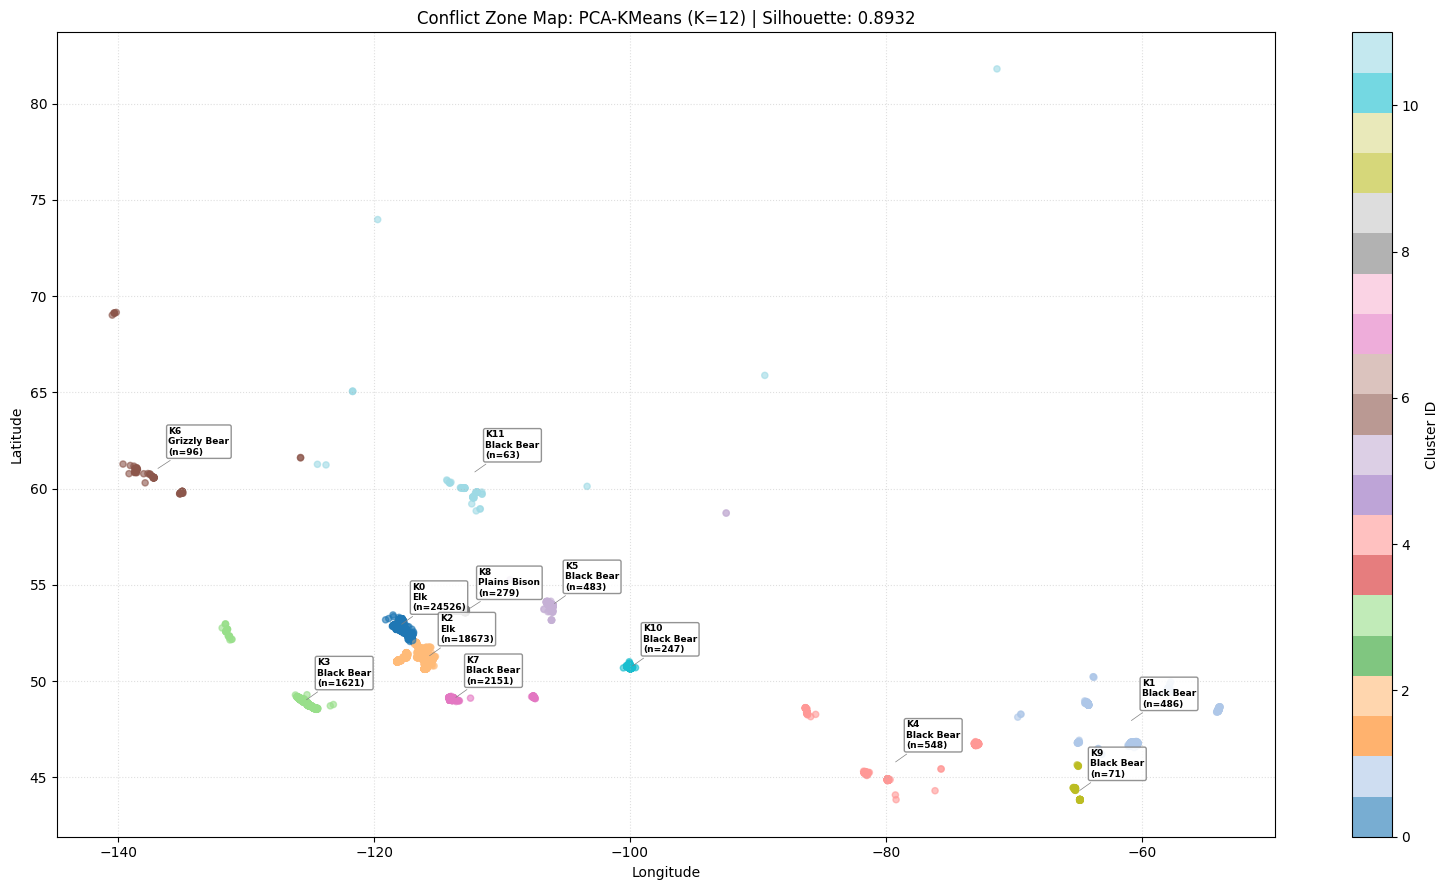

In [ ]:
plt.figure(figsize=(16, 9))
scatter = plt.scatter(
    df_cluster['Longitude'], df_cluster['Latitude'],
    c=df_cluster['PCA_Cluster'], cmap='tab20',
    s=20, alpha=0.6
)
plt.colorbar(scatter, label='Cluster ID')

# Add a label at the center of each KMeans cluster
for _, row in pca_report.iterrows():
    plt.annotate(
        f"K{int(row['PCA_Cluster'])}\n{row['Primary_Species']}\n(n={int(row['Incident_Count'])})",
        xy=(row['Center_Lon'], row['Center_Lat']),
        xytext=(row['Center_Lon'] + 1.0, row['Center_Lat'] + 0.8),
        fontsize=6.5, weight='bold',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey',
                  boxstyle='round,pad=0.2'),
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
        zorder=3
    )

plt.title(f'Conflict Zone Map: PCA-KMeans (K={best_k}) | Silhouette: {pca_score:.4f}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 15 — DBSCAN vs KMeans Comparison Summary

In [ ]:
print("============================================")
print("     DBSCAN vs PCA-KMeans Comparison")
print("============================================")
print(f"  DBSCAN Silhouette Score  : {db_score:.3f}")
print(f"  KMeans Silhouette Score  : {pca_score:.3f} (K={best_k})")
print(f"  DBSCAN Clusters Found    : {n_clusters}")
print(f"  KMeans Clusters (K)      : {best_k}")
print(f"  DBSCAN Noise Points      : {n_noise} ({n_noise/len(df_cluster)*100:.1f}%)")
print(f"  KMeans Noise Points      : 0 (every point assigned to a cluster)")
print("--------------------------------------------")
print("  DBSCAN: precise hotspots, noise filtering,")
print("  arbitrary cluster shapes — best for")
print("  operational real-time conflict alerts.")
print("--------------------------------------------")
print("  KMeans K=12: broad park-level zones,")
print("  caught sparse northern regions DBSCAN")
print("  missed — best for strategic planning.")
print("============================================")

     DBSCAN vs PCA-KMeans Comparison
  DBSCAN Silhouette Score  : 0.789
  KMeans Silhouette Score  : 0.893 (K=12)
  DBSCAN Clusters Found    : 40
  KMeans Clusters (K)      : 12
  DBSCAN Noise Points      : 333 (0.7%)
  KMeans Noise Points      : 0 (every point assigned to a cluster)
--------------------------------------------
  DBSCAN: precise hotspots, noise filtering,
  arbitrary cluster shapes — best for
  operational real-time conflict alerts.
--------------------------------------------
  KMeans K=12: broad park-level zones,
  caught sparse northern regions DBSCAN
  missed — best for strategic planning.


## Step 16 — Export Cluster Results for Backend

In [ ]:
import joblib

# ── DBSCAN exports ──
# Only keep DBSCAN-relevant columns
df_dbscan_export = df_cluster[['Latitude', 'Longitude', 'SPECIES',
                                'RISK_LEVEL', 'Field_Unit', 'Month',
                                'Year', 'DBSCAN_Cluster']].copy()

df_dbscan_export.to_csv(
    '/content/drive/MyDrive/parks_canada_dbscan_clusters.csv',
    index=False
)
db_report.to_csv(
    '/content/drive/MyDrive/parks_canada_dbscan_hotspot_summary.csv',
    index=False
)
joblib.dump(dbscan, '/content/drive/MyDrive/parks_canada_dbscan_model.joblib')

# ── KMeans exports ──
# Only keep KMeans-relevant columns
df_kmeans_export = df_cluster[['Latitude', 'Longitude', 'SPECIES',
                                'RISK_LEVEL', 'Field_Unit', 'Month',
                                'Year', 'PCA_Cluster']].copy()

df_kmeans_export.to_csv(
    '/content/drive/MyDrive/parks_canada_kmeans_clusters.csv',
    index=False
)
pca_report.to_csv(
    '/content/drive/MyDrive/parks_canada_kmeans_zone_summary.csv',
    index=False
)
joblib.dump(km_final, '/content/drive/MyDrive/parks_canada_kmeans_model.joblib')

print("DBSCAN exports:")
print("  parks_canada_dbscan_clusters.csv         — points with DBSCAN_Cluster column only")
print("  parks_canada_dbscan_hotspot_summary.csv  — per-hotspot summary")
print("  parks_canada_dbscan_model.joblib         — fitted DBSCAN model")
print()
print("KMeans exports:")
print("  parks_canada_kmeans_clusters.csv         — points with PCA_Cluster column only")
print("  parks_canada_kmeans_zone_summary.csv     — per-zone summary")
print("  parks_canada_kmeans_model.joblib         — fitted KMeans model")

DBSCAN exports:
  parks_canada_dbscan_clusters.csv         — points with DBSCAN_Cluster column only
  parks_canada_dbscan_hotspot_summary.csv  — per-hotspot summary
  parks_canada_dbscan_model.joblib         — fitted DBSCAN model

KMeans exports:
  parks_canada_kmeans_clusters.csv         — points with PCA_Cluster column only
  parks_canada_kmeans_zone_summary.csv     — per-zone summary
  parks_canada_kmeans_model.joblib         — fitted KMeans model
